# Rasterio: Reading and Visualizing

To get started, you’ll need to import rasterio along with a few other useful Python libraries. These libraries will allow us to perform different types of geospatial operations, manipulate arrays, and visualize raster data.

In [1]:
import numpy
import rasterio

To read raster data, you can use the rasterio.open() function. This function creates a connection to the file without loading the entire dataset into memory. This is particularly useful for large datasets like satellite imagery or high-resolution DEMs, as they might be too big to fit into memory at once.

In this example, we are opening a DEM (digital elevation model) raster file from a URL:

In [2]:
src = rasterio.open('https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif')
print(src)

<open DatasetReader name='https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif' mode='r'>


Here, rasterio.open() returns a DatasetReader object that allows us to interact with the raster data file. This object provides access to various attributes and methods to read the raster's metadata and pixel values.

## Getting Basic Raster Information

Once the raster file is opened, you can retrieve metadata about the raster, including its coordinate reference system (CRS), resolution, bounds, number of bands, and data type. Here’s how you can access some of the essential properties:

In [3]:
# file name
src.name

'https://github.com/opengeos/datasets/releases/download/raster/dem_90m.tif'

The mode attribute shows how the file was opened. For example, a raster can be opened in read-only ('r') or write ('w') mode.

In [4]:
src.mode

'r'

he meta attribute provides key information about the raster, such as its width, height, CRS, number of bands, and data type.

In [5]:
src.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': None,
 'width': 4269,
 'height': 3113,
 'count': 1,
 'crs': CRS.from_epsg(3857),
 'transform': Affine(90.0, 0.0, -13442488.3428,
        0.0, -89.99579177642138, 4668371.5775)}

he CRS describes how the 2D pixel values relate to real-world geographic coordinates (latitude and longitude or projected coordinates). Knowing the CRS is essential for interpreting the data in a meaningful way. The CRS can be retrieved in two ways:

In [6]:
src.crs

CRS.from_epsg(3857)

In [7]:
src.meta['crs']

CRS.from_epsg(3857)

The resolution of a raster refers to the size of one pixel in real-world units (e.g., meters). You can access the resolution using the res attribute:

In [8]:
src.res

(90.0, 89.99579177642138)

The width and height provide the number of pixels along the x-axis and y-axis, respectively. These numbers indicate the grid’s size in pixels.

In [9]:
print(src.width, src.height)

4269 3113


The bounds attribute provides the geographical extent of the raster dataset, represented by the coordinates of the edges of the raster (left, bottom, right, top).

In [10]:
src.bounds

BoundingBox(left=-13442488.3428, bottom=4388214.6777, right=-13058278.3428, top=4668371.5775)

The dtypes attribute gives you the data type of each pixel value (e.g., uint8, int16, float32). This is important when performing mathematical operations on the raster data.

In [11]:
src.dtypes

('int16',)

The affine transformation matrix maps pixel coordinates to geographic coordinates. This transform is essential for understanding how the pixel locations relate to real-world coordinates.

In [12]:
src.transform

Affine(90.0, 0.0, -13442488.3428,
       0.0, -89.99579177642138, 4668371.5775)

The transformation matrix consists of six parameters that control the scaling, translation, and rotation of the raster. Most rasters will have no rotation (b, d are 0), but the transformation will include the pixel size (a, e) and the geographic coordinates of the top-left pixel (c, f).

- a: width of a pixel in the x-direction

- b: row rotation (typically zero)

- c: x-coordinate of the upper-left corner of the upper-left pixel

- d: column rotation (typically zero)

- e: height of a pixel in the y-direction (typically negative)

- f: y-coordinate of the of the upper-left corner of the upper-left pixel

a and e are the pixel width and height, respectively, and c and f are the coordinates of the upper-left corner of the raster. The other coefficients are used for rotation and shearing.

## Plotting Raster Data

Rasterio can easily integrate with matplotlib for raster visualization. The rasterio.plot.show() function is the simplest way to display a raster image, and by default, it shows the first band of the raster.

Here, we plot the raster using the `rasterio.plot.show()` method. But first we have to import the rasterio plot (sub-)module.

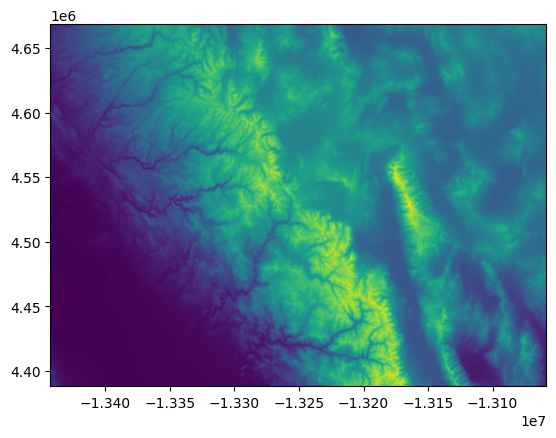

In [13]:
import rasterio.plot

rasterio.plot.show(src);

The `show()` function automatically handles the raster's georeferencing, ensuring that the raster is displayed in its correct geographic position.

Rasterio supports multi-band rasters (e.g., satellite imagery). To display a specific band, you can pass the band number as a tuple along with the dataset object.

In geospatial data, bands refer to different layers of data (e.g., red, green, blue, infrared for satellite images). **The band index in rasterio is 1-based**, so band 1 refers to the first band in the dataset!

Here, we plot the first band:

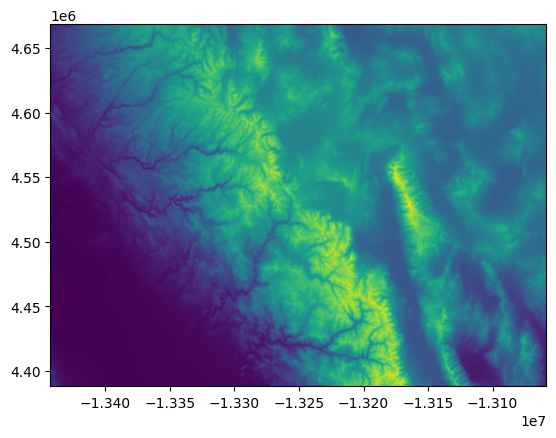

In [14]:
rasterio.plot.show((src, 1));

You can further enhance your plots with color maps and titles. Here's an example that customizes the colormap to terrain and adds a title to the plot:

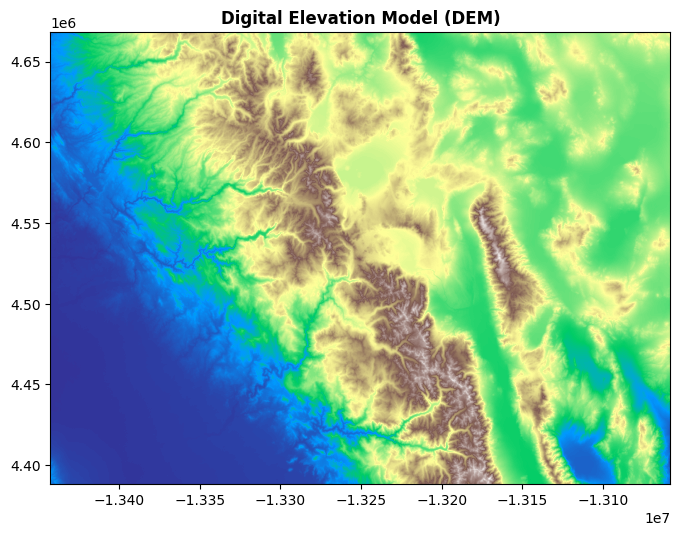

In [15]:
import matplotlib.pylab as plt

fig, ax = plt.subplots(figsize=(8, 8))

rasterio.plot.show(src, cmap="terrain", ax=ax, title="Digital Elevation Model (DEM)")

plt.show()

## Plotting a Vector Layer on Top of a Raster Image

In geospatial analysis, it is common to overlay vector data on top of raster images to provide additional context. Vector data often represents boundaries, roads, or other features, while raster data represents continuous fields like elevation or temperature. For instance, we might want to plot a vector boundary over a Digital Elevation Model (DEM) raster. In this example, we load a GeoJSON file containing vector data, ensure it has the same CRS as the raster, and plot it on top of the DEM.

First, let's load the vector data and reproject it to match the CRS of the raster:

In [16]:
import geopandas as gpd

gdf = gpd.read_file("https://github.com/opengeos/datasets/releases/download/places/dem_bounds.geojson")
gdf = gdf.to_crs(src.crs)

The vector data is read using `geopandas.read_file()`, and then we ensure the vector data's CRS matches the CRS of the raster using `gdf.to_crs(src.crs)`. This step is critical to ensure proper alignment between the raster and vector layers.

Next, we can plot the DEM raster and overlay the vector data:

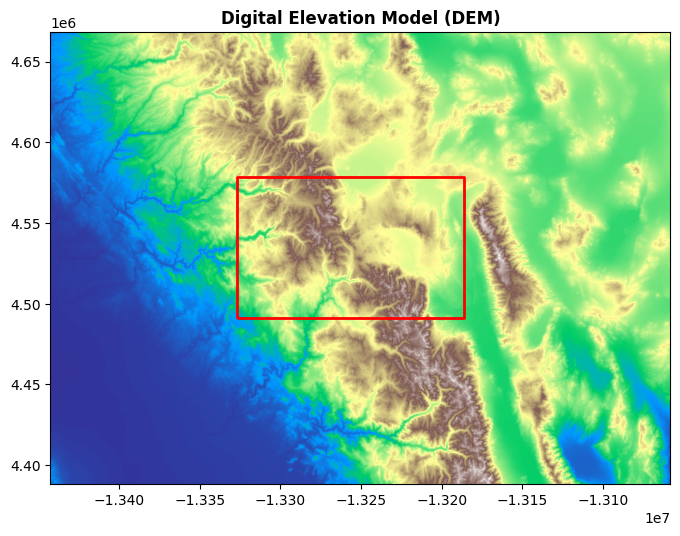

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))

rasterio.plot.show(src, cmap="terrain", ax=ax, title="Digital Elevation Model (DEM)")

gdf.plot(ax=ax, edgecolor="red", facecolor="none", lw=2);

In this block, we use `rasterio.plot.show()` to plot the raster data, using the "terrain" colormap to visualize the elevation changes. We then overlay the vector boundary on top using `gdf.plot()`. The `dgecolor='red'` sets the boundary color to red, and `facecolor='none'` ensures the interior of the boundary remains transparent, making it easier to view the raster underneath.

Question: what does the `lw` keyword do?

When visualizing raster data, colormaps help map pixel values to colors, while colorbars provide a scale reference for interpreting the pixel values. In this example, we will plot the first band of the DEM with a custom colormap ('terrain') and add a colorbar to better interpret the elevation values.

Let's read the first band and plot it with a colormap:

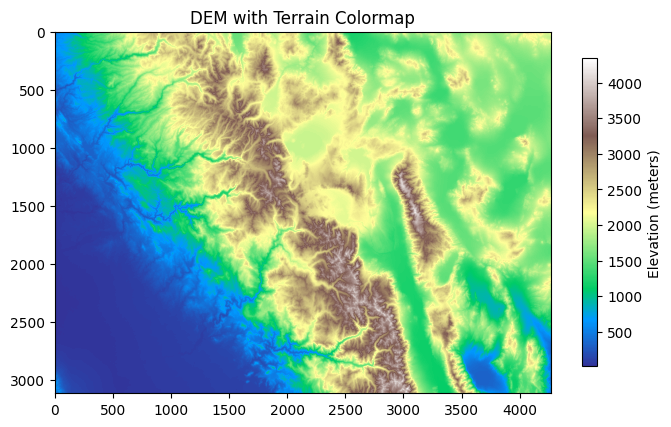

In [18]:
elev_band = src.read(1)
plt.figure(figsize=(8, 8))
plt.imshow(elev_band, cmap="terrain")
plt.colorbar(label="Elevation (meters)", shrink=0.5)
plt.title("DEM with Terrain Colormap")
plt.show()

Here, we read the first band of the raster using `src.read(1)`, which corresponds to the elevation data of the DEM. The `plt.imshow()` function displays the raster using the 'terrain' colormap. We also add a colorbar using `plt.colorbar()` to provide a reference for interpreting the elevation values, and the `shrink=0.5` option scales the colorbar to fit the figure.

The plot shows the DEM with a color map that highlights different elevations using the 'terrain' color scheme. The colorbar provides a clear scale to understand how the pixel values (representing elevation in meters) are distributed. The plot also has a title to provide additional context.